In [1]:
# Core libraries
import pandas as pd
import numpy as np
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Project config
from src.params import *

# Plot configuration
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# General outline for EDA 

### Phase I: Data Quality
**To look at:**
- Overall aspect of sample PM2.5 curves
- % day availability per city/sensor
- Number, max length and distribution across the train set of missing days
- time distribution of sensors
- Distribution of intra-day coverage per sensor
- Aberrant values (high or low), frequency and distribution across train set

**Output:**
- Threshold for filtering out sensors with day availability below x% of total days
- Decision on max gap length acceptable (interpolation vs suppression)
- List of cities to remove because insufficient data quality
- Decision on handling aberrant data
- First city reduction based on data quality (target: 5-7 cities from 12)


### Phase II: Sensor Metrics and Aggregation
**To look at:**
- Correlation between same-city sensors
- Inter-sensor variance
- Temporal stability of sensors

**Output:**
- Coverage threshold per day for filtering out unreliable sensors (if needed)
- min sensors to keep a city
- Rule of aggregation: simple average? weighted average by coverage?


### Phase III: Target Distribution
**To look at:**
- Shape of PM2.5 distributions (after sensor aggregation)
- Distribution of values 
- Outliers detection and frequency

**Output:**
- Decision on log transformation
- Choice of metric: RMSE vs RMSLE vs MAE 


### Phase IV: Temporal Patterns
**To look at:**
- Trend over time
- Seasonality (monthly patterns)
- Distribution of day-to-day changes
- Volatility: rolling std sur 7d/30d 

**Output:**
- Knowledge about general behavior, extreme periods
- Decision on retraining frequency 


### Phase V: Autocorrelation
**To look at:**
- ACF/PACF plots per city
- Identification of significant lags

**Output:**
- Relevant lookback window (e.g., 7 days, 14 days, 30 days)
- List of lags to include as features (e.g., all individual lags from 1 to 7, or specific lags: 1, 7, 14, 30)
- Alternative: decision on using rolling features (mean/std) vs individual lags


### Phase VI: Inter-City Comparison
**To look at:**
- Value distributions between cities
- Temporal patterns comparison across cities
- Cross-correlation between cities (pattern similarity)

**Output:**
- Decision on model architecture: 1 global model + city feature OR separate models per city
- Final city selection: keep 5-7 cities with best data quality 


# I. Quality check 
- missing days : number, max duration, distribution
- aberrant values (negatives)
- decision on filtering out sensors and cities

In [2]:
#loading df
df_weather = pd.read_csv("../data/raw/weather.csv")
df_airqual = pd.read_csv("../data/raw/aq_data.csv")

In [3]:
#convert date in pd datetime format
df_weather["date"] = pd.to_datetime(df_weather["date"])
df_airqual["date"] = pd.to_datetime(df_airqual["date_from_local"].str[:10])


In [4]:
#check no missing days in weather
df_weather["date"].dt.day.diff().max()

np.float64(1.0)

In [5]:
df_airqual.head()

,sensor_id,date_from_utc,date_from_local,date_to_utc,date_to_local,pm25_avg,pm25_min,pm25_q25,pm25_median,pm25_q75,pm25_max,coverage,city,date
0,1582598,2023-04-30T22:00:00Z,2023-05-01T00:00:00+02:00,2023-05-01T22:00:00Z,2023-05-02T00:00:00+02:00,16.00,4.9,10.675,15.05,19.650,32.0,100.0,Paris,2023-05-01
1,1582598,2023-05-01T22:00:00Z,2023-05-02T00:00:00+02:00,2023-05-02T22:00:00Z,2023-05-03T00:00:00+02:00,12.60,6.6,9.650,10.90,15.600,21.9,100.0,Paris,2023-05-02
2,1582598,2023-05-02T22:00:00Z,2023-05-03T00:00:00+02:00,2023-05-03T22:00:00Z,2023-05-04T00:00:00+02:00,11.60,4.8,9.900,12.25,13.800,17.6,100.0,Paris,2023-05-03
3,1582598,2023-05-03T22:00:00Z,2023-05-04T00:00:00+02:00,2023-05-04T22:00:00Z,2023-05-05T00:00:00+02:00,8.96,3.9,7.825,9.40,10.700,11.9,100.0,Paris,2023-05-04
4,1582598,2023-05-04T22:00:00Z,2023-05-05T00:00:00+02:00,2023-05-05T22:00:00Z,2023-05-06T00:00:00+02:00,5.07,0.4,3.875,4.65,6.425,9.6,100.0,Paris,2023-05-05


## Abnormal data 

In [ ]:
#count negative values
neg_values = df_airqual.groupby(["city", "sensor_id"])["pm25_avg"].agg([("total", "count"),
                                                                        ("neg_values", lambda x: (x<0).sum())])
neg_values["pct_neg"] = neg_values["neg_values"] / neg_values["total"]*100
neg_values

total  neg_values    pct_neg
city        sensor_id                              
Barcelona   4273113      626           0   0.000000
Berlin      1300111      712           0   0.000000
            1300115      712           0   0.000000
            1300119      707           0   0.000000
Delhi       23534        731         196  26.812585
London      249          705           0   0.000000
            28890        695           0   0.000000
            1304692      673           0   0.000000
            1304737      719           0   0.000000
            1561901      635           0   0.000000
            1666368      659           2   0.303490
            6933605      593           0   0.000000
Los Angeles 25196        694           1   0.144092
Lyon        7922         675          25   3.703704
            8559         714           0   0.000000
            24867        710           0   0.000000
New York    673          725           7   0.965517
            1097         672           7   1.041667
            1102         719           0   0.000000
            1146         731           0   0.000000
            1534         713           3   0.420757
            1662910      726          12   1.652893
Paris       9548         685          27   3.941606
            1562368      688          30   4.360465
            1582598      673          38   5.646360
Rome        21806        699           0   0.000000
            21841        631           0   0.000000
            21846        698           0   0.000000
            21857        682           0   0.000000
Santiago    3190         671           0   0.000000
            4100         669           0   0.000000

**Conclusion**: er of neg value in Delhi, consider dropping. 
For now, I'll delete rows with neg values bc non-usable. (we'll see if imputing later on after analysis of gaps)

In [7]:
df = df_airqual[df_airqual["pm25_avg"] > 0].copy()


## gap analysis

**questions**
- how many gap in data? 
- how long max gap? 
- are gaps distributed evenly across the train set? 

**how gaps matter**
- gap in data may be problematic if it hinders the model from learning a specific pattern, and reduce the overall data size (already small)
- it the lookback window turns to be small (7-14 days) we can tolerate longer gaps (still a large number of usable windows)
- if the data drifts rapidly, we cannot tolerate long gaps (data distribution or pattern changes quickly so we need to see many "examples" of time sequence)
- given the train set is 2 years, if we have a gap in one month it may be ok if we have data in the other month to support it. 

In [ ]:
#check number, duration, of gaps in airqual

#get the time dff between rows in number of days
df["delta"] = df.groupby("sensor_id")["date"].diff().dt.days

#select only rows where there's a gap
gaps = df[df["delta"] > 1]

#stats on gap
gap_stats= gaps.groupby(["city", "sensor_id"])["delta"].agg(["count", "max", "median", ("q75", lambda x: x.quantile(0.75))])
gap_stats

count   max  median    q75
city        sensor_id                            
Barcelona   4273113       53  35.0     2.0   2.00
Berlin      1300111        8   7.0     3.0   3.50
            1300115        8   7.0     3.0   3.50
            1300119       10   7.0     3.0   3.75
Delhi       23534         21  55.0     2.0   5.00
London      249            9  11.0     2.0   5.00
            28890         17   6.0     3.0   4.00
            1304692        4  11.0     9.5  10.25
            1304737        6   4.0     3.0   3.75
            1561901       12  27.0     6.5  11.25
            1666368       13  12.0     7.0  10.00
            6933605        2   5.0     3.5   4.25
Los Angeles 25196          5  30.0     4.0   4.00
Lyon        7922          39   7.0     2.0   3.50
            8559           8   7.0     2.0   3.50
            24867          8   7.0     2.5   5.25
New York    673            7   6.0     2.0   3.00
            1097           9  54.0     2.0   3.00
            1102           8   5.0     2.0   2.25
            1534           7   7.0     2.0   3.50
            1662910       13   6.0     2.0   2.00
Paris       9548          37   7.0     2.0   4.00
            1562368       37   7.0     2.0   3.00
            1582598       37  16.0     2.0   4.00
Rome        21806         16   8.0     2.0   3.25
            21841         32  13.0     3.0   5.00
            21846         22   5.0     2.0   2.75
            21857         23  13.0     3.0   3.00
Santiago    3190           8  51.0     2.0   2.75
            4100          10  28.0     2.0  10.25

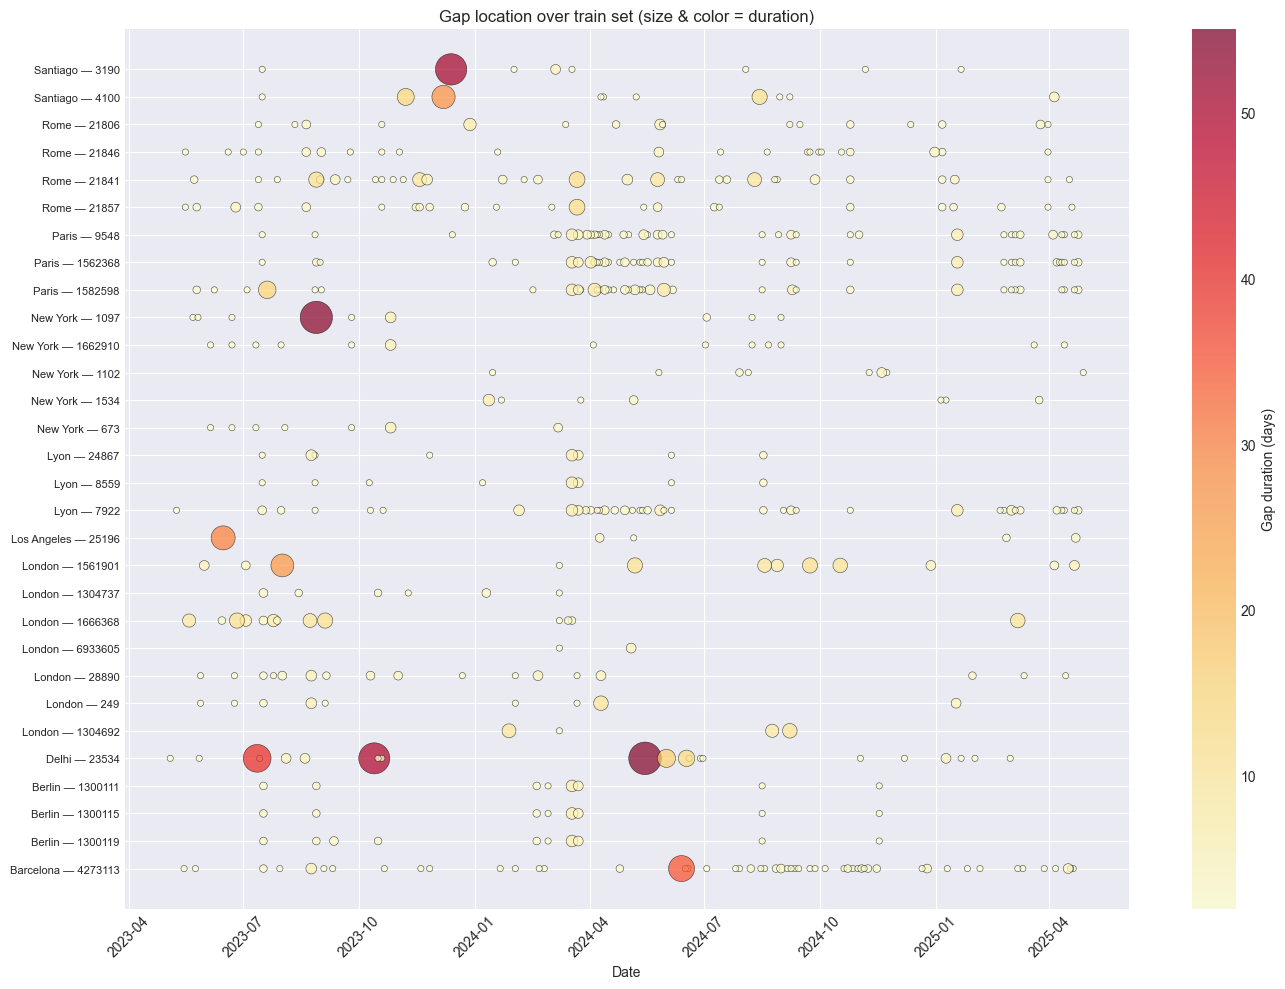

In [ ]:
#vizualization distribution and duration of gaps over the train period (AI-generated code)
def plot_gaps_over_time(gaps, sensor_col="sensor_id", date_col="date", duration_col="delta"):
    fig, ax = plt.subplots(figsize=(14, 10))
    gaps = gaps.sort_values(by=["city"])
    sensors = gaps[sensor_col].unique()
    labels = [f"{gaps[gaps[sensor_col]==s]['city'].iloc[0]} — {s}" for s in sensors]
    sensor_to_y = {s: i for i, s in enumerate(sensors)}

    scatter = ax.scatter(
        x=gaps[date_col],
        y=gaps[sensor_col].map(sensor_to_y),
        s=gaps[duration_col] * 10,      # taille proportionnelle au gap
        c=gaps[duration_col],            # couleur proportionnelle au gap
        cmap="YlOrRd",
        alpha=0.7,
        edgecolors="black",
        linewidths=0.4
    )

    plt.colorbar(scatter, ax=ax, label="Gap duration (days)")
    ax.set_yticks(range(len(sensors)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Date")
    ax.set_title("Gap location over train set (size & color = duration)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_gaps_over_time(gaps)

In [ ]:
#monthly coverage: how many days per months have measurements.
coverage_monthly = df.groupby(["city", "sensor_id", pd.Grouper(key= "date", freq= "ME")]).size().reset_index(name= "nb_readings")


In [ ]:
coverage_monthly["days_in_month"] = coverage_monthly["date"].dt.days_in_month
coverage_monthly["coverage_pct"] = coverage_monthly["nb_readings"] / coverage_monthly["days_in_month"]*100


In [13]:
coverage_monthly

,city,sensor_id,date,nb_readings,days_in_month,coverage_pct
0,Barcelona,4273113,2023-05-31,29,31,93.548387
1,Barcelona,4273113,2023-06-30,30,30,100.000000
2,Barcelona,4273113,2023-07-31,28,31,90.322581
3,Barcelona,4273113,2023-08-31,26,31,83.870968
4,Barcelona,4273113,2023-09-30,28,30,93.333333
...,...,...,...,...,...,...
731,Santiago,4100,2024-12-31,31,31,100.000000
732,Santiago,4100,2025-01-31,31,31,100.000000
733,Santiago,4100,2025-02-28,28,28,100.000000
734,Santiago,4100,2025-03-31,31,31,100.000000


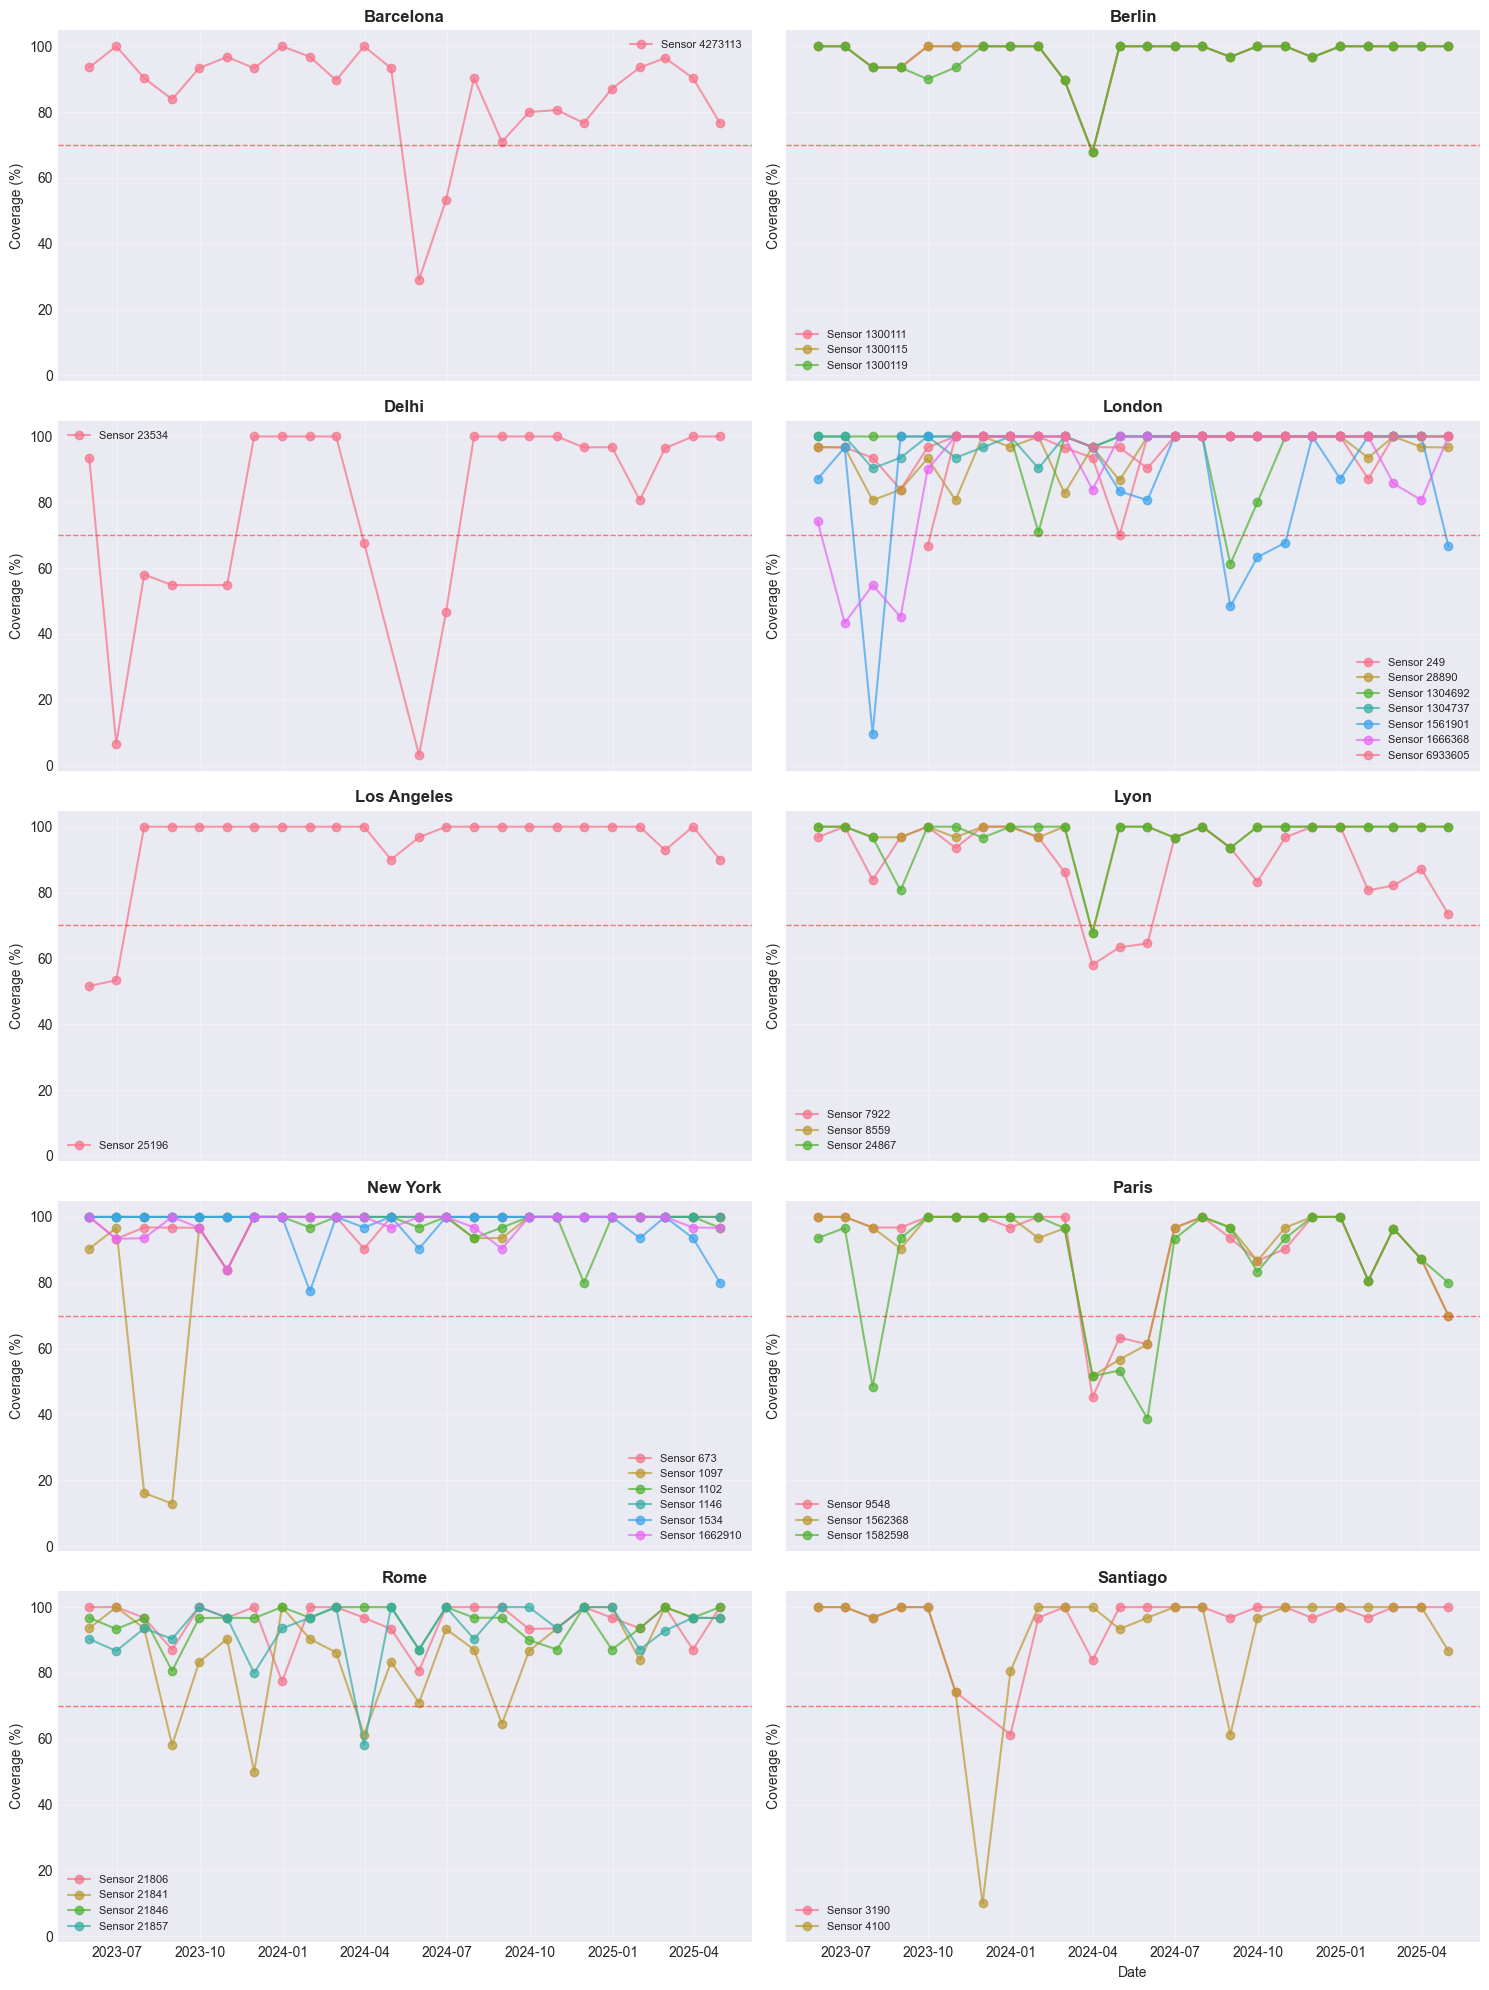

In [ ]:
#visualization % coverage per month
def plot_sensor_coverage_by_city(coverage_monthly):
    """
    Plot coverage % par sensor, un subplot par ville
    """
    cities = coverage_monthly['city'].unique()
    n_cities = len(cities)

    # Définir grid (2 colonnes)
    n_cols = 2
    n_rows = (n_cities + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), sharex=True, sharey=True)
    axes = axes.flatten() if n_cities > 1 else [axes]

    for i, city in enumerate(cities):
        ax = axes[i]
        city_data = coverage_monthly[coverage_monthly['city'] == city]

        # Plot chaque sensor
        for sensor in city_data['sensor_id'].unique():
            sensor_data = city_data[city_data['sensor_id'] == sensor]
            ax.plot(sensor_data['date'], sensor_data['coverage_pct'],
                   label=f'Sensor {sensor}', marker='o', alpha=0.7)

        ax.axhline(y=70, color='r', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_title(f'{city}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Coverage (%)')
        ax.legend(fontsize=8, loc='best')
        ax.grid(alpha=0.3)

    # Supprimer axes vides
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.xlabel('Date')
    plt.tight_layout()
    plt.show()

# Utilisation
plot_sensor_coverage_by_city(coverage_monthly)

## Filtering out sensors

In [15]:
# Filter out sensor with gap > max_gap
max_gap = 30 #filtering sensors with a gap longer than one month
sensors_out_max_gap = gap_stats[gap_stats["max"] >= max_gap].index.get_level_values("sensor_id").tolist()
sensors_out_max_gap

[4273113, 23534, 25196, 1097, 3190]

In [32]:
#filter out sensor with 75% quartile above 10 (25% gaps more than 10 days )
max_q = 10.0
sensors_out_max_q = gap_stats[gap_stats["q75"] >= max_q].index.get_level_values("sensor_id").tolist()
sensors_out_max_q

[1304692, 1561901, 1666368, 4100]

In [ ]:
#filter out sensors with a lot of month with "badh coverage"
min_coverage_pct = 70 #a bad month = month with less that 70% of days covered
min_bad_month_pct= 0.20 # need at least 80% of good month to be kepted

#count total number of months
coverage_monthly["bad_months"] = (coverage_monthly["coverage_pct"] < min_coverage_pct).astype(int)

bad_month_ratio = coverage_monthly.groupby(["city", "sensor_id"])["bad_months"].mean().reset_index(name= "bad_months_pct")
sensor_out_bad_months = bad_month_ratio[bad_month_ratio["bad_months_pct"] > min_bad_month_pct]["sensor_id"].tolist()
sensor_out_bad_months


[23534, 1561901]

In [34]:
sensors_to_remove = set(sensor_out_bad_months + sensors_out_max_q + sensors_out_max_gap)
print(sensors_to_remove)
df_filtered = df[~df["sensor_id"].isin(sensors_to_remove)]
df_filtered

{1666368, 4100, 1097, 25196, 1561901, 23534, 1304692, 3190, 4273113}


,sensor_id,date_from_utc,date_from_local,date_to_utc,date_to_local,pm25_avg,pm25_min,pm25_q25,pm25_median,pm25_q75,pm25_max,coverage,city,date,delta
0,1582598,2023-04-30T22:00:00Z,2023-05-01T00:00:00+02:00,2023-05-01T22:00:00Z,2023-05-02T00:00:00+02:00,16.00,4.9,10.675,15.05,19.650,32.0,100.0,Paris,2023-05-01,NaN
1,1582598,2023-05-01T22:00:00Z,2023-05-02T00:00:00+02:00,2023-05-02T22:00:00Z,2023-05-03T00:00:00+02:00,12.60,6.6,9.650,10.90,15.600,21.9,100.0,Paris,2023-05-02,1.0
2,1582598,2023-05-02T22:00:00Z,2023-05-03T00:00:00+02:00,2023-05-03T22:00:00Z,2023-05-04T00:00:00+02:00,11.60,4.8,9.900,12.25,13.800,17.6,100.0,Paris,2023-05-03,1.0
3,1582598,2023-05-03T22:00:00Z,2023-05-04T00:00:00+02:00,2023-05-04T22:00:00Z,2023-05-05T00:00:00+02:00,8.96,3.9,7.825,9.40,10.700,11.9,100.0,Paris,2023-05-04,1.0
4,1582598,2023-05-04T22:00:00Z,2023-05-05T00:00:00+02:00,2023-05-05T22:00:00Z,2023-05-06T00:00:00+02:00,5.07,0.4,3.875,4.65,6.425,9.6,100.0,Paris,2023-05-05,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19371,21857,2025-04-25T22:00:00Z,2025-04-26T00:00:00+02:00,2025-04-26T22:00:00Z,2025-04-27T00:00:00+02:00,5.00,5.0,5.000,5.00,5.000,5.0,4.0,Rome,2025-04-26,1.0
19372,21857,2025-04-26T22:00:00Z,2025-04-27T00:00:00+02:00,2025-04-27T22:00:00Z,2025-04-28T00:00:00+02:00,6.00,6.0,6.000,6.00,6.000,6.0,4.0,Rome,2025-04-27,1.0
19373,21857,2025-04-27T22:00:00Z,2025-04-28T00:00:00+02:00,2025-04-28T22:00:00Z,2025-04-29T00:00:00+02:00,9.00,9.0,9.000,9.00,9.000,9.0,4.0,Rome,2025-04-28,1.0
19374,21857,2025-04-28T22:00:00Z,2025-04-29T00:00:00+02:00,2025-04-29T22:00:00Z,2025-04-30T00:00:00+02:00,9.00,9.0,9.000,9.00,9.000,9.0,4.0,Rome,2025-04-29,1.0


In [35]:
gaps_filtered = df_filtered[df_filtered["delta"] > 1]
gap_stats_filtered= gaps_filtered.groupby(["city", "sensor_id"])["delta"].agg(["count", "max", "median", ("q75", lambda x: x.quantile(0.75))])
gap_stats_filtered

count   max  median   q75
city     sensor_id                           
Berlin   1300111        8   7.0     3.0  3.50
         1300115        8   7.0     3.0  3.50
         1300119       10   7.0     3.0  3.75
London   249            9  11.0     2.0  5.00
         28890         17   6.0     3.0  4.00
         1304737        6   4.0     3.0  3.75
         6933605        2   5.0     3.5  4.25
Lyon     7922          39   7.0     2.0  3.50
         8559           8   7.0     2.0  3.50
         24867          8   7.0     2.5  5.25
New York 673            7   6.0     2.0  3.00
         1102           8   5.0     2.0  2.25
         1534           7   7.0     2.0  3.50
         1662910       13   6.0     2.0  2.00
Paris    9548          37   7.0     2.0  4.00
         1562368       37   7.0     2.0  3.00
         1582598       37  16.0     2.0  4.00
Rome     21806         16   8.0     2.0  3.25
         21841         32  13.0     3.0  5.00
         21846         22   5.0     2.0  2.75
         21857         23  13.0     3.0  3.00

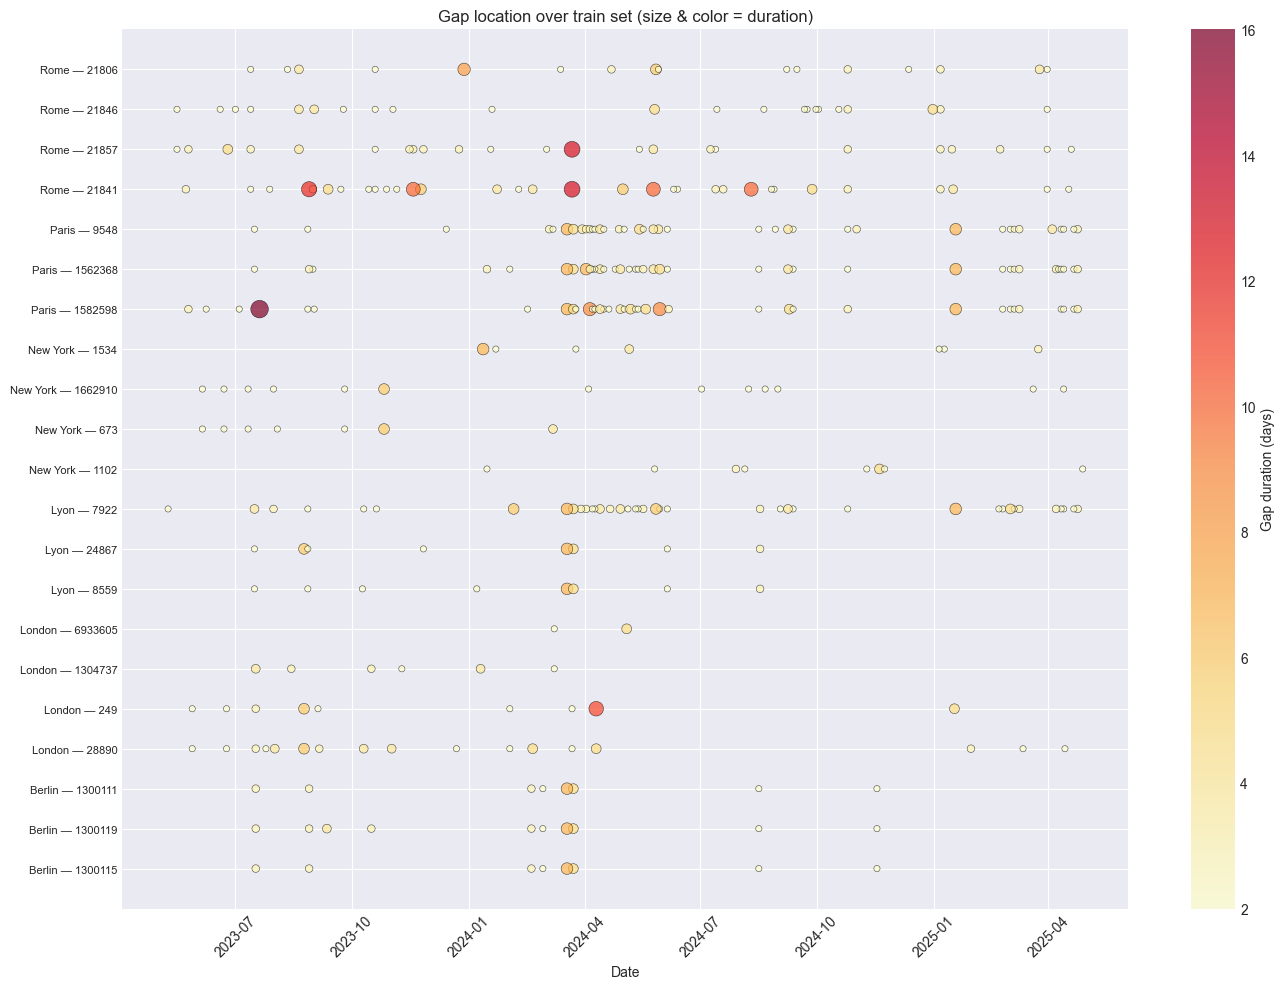

In [36]:
plot_gaps_over_time(gaps_filtered)

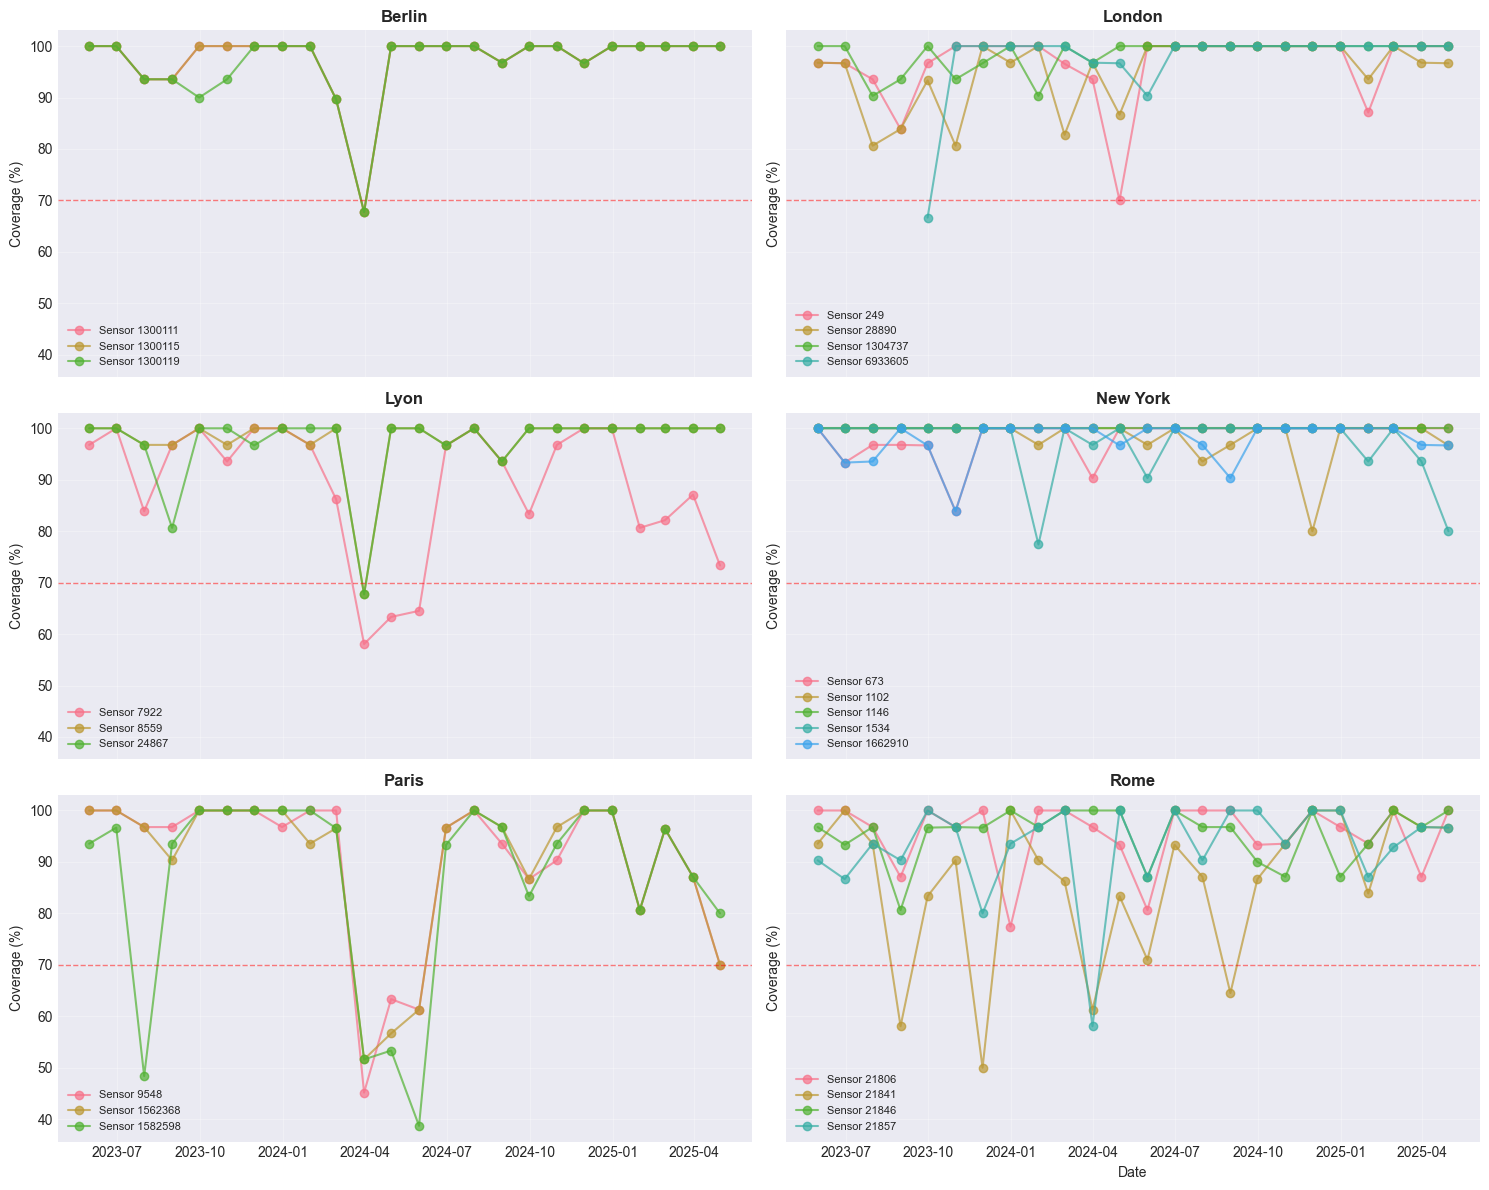

In [ ]:
#monthly coverage: how many days per months have measurements.
coverage_monthly_filtered = df_filtered.groupby(["city", "sensor_id", pd.Grouper(key= "date", freq= "ME")]).size().reset_index(name= "nb_readings")
coverage_monthly_filtered["days_in_month"] = coverage_monthly_filtered["date"].dt.days_in_month
coverage_monthly_filtered["coverage_pct"] = coverage_monthly_filtered["nb_readings"] / coverage_monthly_filtered["days_in_month"]*100
plot_sensor_coverage_by_city(coverage_monthly_filtered)


In [109]:
coverage_monthly_filtered

,city,sensor_id,date,nb_readings,days_in_month,coverage_pct
0,Berlin,1300111,2023-05-31,31,31,100.000000
1,Berlin,1300111,2023-06-30,30,30,100.000000
2,Berlin,1300111,2023-07-31,29,31,93.548387
3,Berlin,1300111,2023-08-31,29,31,93.548387
4,Berlin,1300111,2023-09-30,30,30,100.000000
...,...,...,...,...,...,...
519,Rome,21857,2024-12-31,31,31,100.000000
520,Rome,21857,2025-01-31,27,31,87.096774
521,Rome,21857,2025-02-28,26,28,92.857143
522,Rome,21857,2025-03-31,30,31,96.774194


# Phase II: Sensor Metrics and Aggregation
**To look at:**
- Correlation between same-city sensors
- Inter-sensor variance
- Temporal stability of sensors

**Output:**
- Coverage threshold per day for filtering out unreliable sensors (if needed)
- min sensors to keep a city
- Rule of aggregation: simple average? weighted average by coverage?

In [38]:
df_filtered.head(2)

,sensor_id,date_from_utc,date_from_local,date_to_utc,date_to_local,pm25_avg,pm25_min,pm25_q25,pm25_median,pm25_q75,pm25_max,coverage,city,date,delta
0,1582598,2023-04-30T22:00:00Z,2023-05-01T00:00:00+02:00,2023-05-01T22:00:00Z,2023-05-02T00:00:00+02:00,16.0,4.9,10.675,15.05,19.65,32.0,100.0,Paris,2023-05-01,NaN
1,1582598,2023-05-01T22:00:00Z,2023-05-02T00:00:00+02:00,2023-05-02T22:00:00Z,2023-05-03T00:00:00+02:00,12.6,6.6,9.650,10.90,15.60,21.9,100.0,Paris,2023-05-02,1.0


In [107]:
all_cities = []

for city in df_filtered["city"].unique():

    print(f"correlations of {city} sensors...")
    corr_df = df_filtered[df_filtered["city"] == city].pivot(index= "date", columns= "sensor_id", values= "pm25_avg").corr()
    corr_df_multi = corr_df.stack()
    corr_df_unique_pair = corr_df_multi[corr_df_multi.index.get_level_values(0) < corr_df_multi.index.get_level_values(1)]
    corr_df_unique_pair = corr_df_unique_pair.rename_axis(index= ["sensor_A", "sensor_B"])
    corr_df_unique_pair = corr_df_unique_pair.reset_index()
    corr_df_unique_pair["city"] = city
    corr_df_unique_pair = corr_df_unique_pair.rename(columns={0:"Corr"})
    all_cities.append(corr_df_unique_pair)


sensor_correlation = pd.concat(all_cities)
sensor_correlation

correlations of Paris sensors...
correlations of Lyon sensors...
correlations of New York sensors...
correlations of London sensors...
correlations of Berlin sensors...
correlations of Rome sensors...


,sensor_A,sensor_B,Corr,city
0,9548,1562368,0.901672,Paris
1,9548,1582598,0.815281,Paris
2,1562368,1582598,0.872541,Paris
0,7922,8559,0.876264,Lyon
1,7922,24867,0.886636,Lyon
2,8559,24867,0.974144,Lyon
0,673,1102,0.871465,New York
1,673,1146,0.887636,New York
2,673,1534,0.869651,New York
3,673,1662910,0.908644,New York


# merging weather and air qual 

In [12]:
#check that no missing days in weather df
df_weather["date"].nunique()/(df_weather.shape[0] / df_weather["city"].nunique())

1.0

In [17]:
#merge df matching cities and date, leaving any missing day as NaN for further investigation
df_merged = pd.merge(df_airqual, df_weather, on=["date", "city"], how= "outer")

In [18]:
df_merged.columns
new_order = ["city", "sensor_id","date", 'pm25_avg', 'pm25_min', 'pm25_q25', 'pm25_median',
       'pm25_q75', 'pm25_max', 'coverage','temp_min',
       'temp_max', 'temp_avg', 'cloud_cover', 'humidity', 'precipitation',
       'pressure', 'wind_speed', 'wind_direction' ]
df_merged = df_merged[new_order]

In [50]:
df = df_merged.sort_values(by= ["city", "sensor_id", "date"], ascending= True)

In [ ]:

#ok

np.int64(0)

In [54]:
df[df["city"] == "Santiago"]

,city,sensor_id,date,pm25_avg,pm25_min,pm25_q25,pm25_median,pm25_q75,pm25_max,coverage,temp_min,temp_max,temp_avg,cloud_cover,humidity,precipitation,pressure,wind_speed,wind_direction
28,Santiago,3190.0,2023-05-01,38.9,26.0,37.00,40.5,42.25,44.0,100.0,5.88,17.90,11.890,24.0,52.0,0.0,989.0,4.12,170.0
58,Santiago,3190.0,2023-05-02,36.4,31.0,33.75,37.0,39.00,42.0,100.0,4.84,19.31,12.075,0.0,41.0,0.0,985.0,2.57,50.0
88,Santiago,3190.0,2023-05-03,46.5,42.0,46.00,47.0,48.00,48.0,100.0,8.13,19.90,14.015,0.0,42.0,0.0,992.0,5.14,160.0
118,Santiago,3190.0,2023-05-04,41.3,38.0,39.00,41.0,43.25,46.0,100.0,5.17,19.12,12.145,0.0,55.0,0.0,995.0,4.63,190.0
148,Santiago,3190.0,2023-05-05,59.7,47.0,56.50,62.5,64.00,66.0,100.0,5.84,21.18,13.510,73.0,35.0,0.0,948.0,6.17,170.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6198,Santiago,NaN,2023-12-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.73,26.49,19.610,100.0,51.0,0.0,1016.0,6.69,210.0
6228,Santiago,NaN,2023-12-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.28,29.67,22.475,5.0,35.0,0.0,945.0,6.69,170.0
6258,Santiago,NaN,2023-12-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.49,29.42,22.955,0.0,34.0,0.0,975.0,8.75,220.0
6288,Santiago,NaN,2023-12-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.87,25.38,19.125,0.0,40.0,0.0,947.0,7.72,170.0


In [ ]:
#no missing days in weather so counting NaN resulting from outermerge with give uss the number of days
missing_days = pd.DataFrame()
for city in df_merged["city"].unique():
    missing_days["city"] = city


,city,sensor_id,date,pm25_avg,pm25_min,pm25_q25,pm25_median,pm25_q75,pm25_max,coverage,temp_min,temp_max,temp_avg,cloud_cover,humidity,precipitation,pressure,wind_speed,wind_direction
21062,Paris,1582598.0,2025-04-11,14.90,14.9,14.900,14.90,14.900,14.9,4.0,5.42,21.58,13.500,0.0,56.0,0.00,1023.0,5.14,60.0
21063,Paris,9548.0,2025-04-11,14.70,14.7,14.700,14.70,14.700,14.7,4.0,5.42,21.58,13.500,0.0,56.0,0.00,1023.0,5.14,60.0
21064,Paris,1562368.0,2025-04-11,17.80,17.8,17.800,17.80,17.800,17.8,4.0,5.42,21.58,13.500,0.0,56.0,0.00,1023.0,5.14,60.0
21091,Paris,NaN,2025-04-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.20,21.52,15.360,0.0,45.0,1.84,1008.0,8.23,160.0
21118,Paris,1582598.0,2025-04-13,10.90,10.9,10.900,10.90,10.900,10.9,4.0,12.53,17.56,15.045,75.0,81.0,0.67,1008.0,6.17,230.0
21119,Paris,9548.0,2025-04-13,8.70,8.7,8.700,8.70,8.700,8.7,4.0,12.53,17.56,15.045,75.0,81.0,0.67,1008.0,6.17,230.0
21120,Paris,1562368.0,2025-04-13,7.10,7.1,7.100,7.10,7.100,7.1,4.0,12.53,17.56,15.045,75.0,81.0,0.67,1008.0,6.17,230.0
21148,Paris,1582598.0,2025-04-14,8.15,2.8,6.775,9.65,9.975,10.9,25.0,7.03,20.51,13.770,75.0,62.0,0.00,1008.0,5.66,200.0
21149,Paris,9548.0,2025-04-14,13.60,7.6,10.875,14.30,16.450,18.6,25.0,7.03,20.51,13.770,75.0,62.0,0.00,1008.0,5.66,200.0
21150,Paris,1562368.0,2025-04-14,11.90,6.5,10.425,11.85,13.575,16.8,25.0,7.03,20.51,13.770,75.0,62.0,0.00,1008.0,5.66,200.0


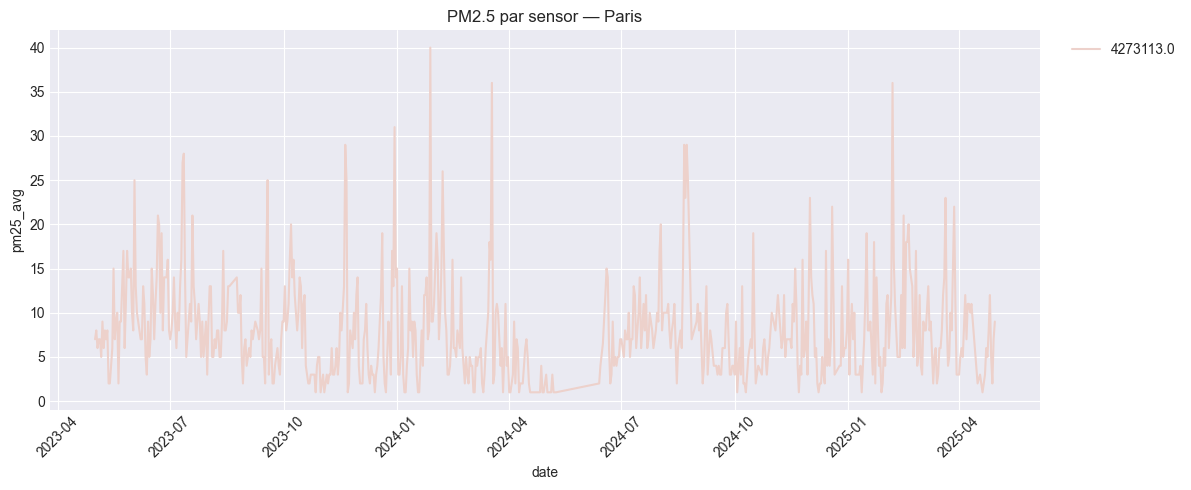

In [93]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_merged[df_merged['city'] == 'Barcelona'], x='date', y='pm25_avg', hue='sensor_id')
plt.title('PM2.5 par sensor — Paris')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##